In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# --- PyTorch Geometric Imports ---
# We will use these for graph data, batching, and GNN layers
import torch_geometric.data
import torch_geometric.nn as gnn
from torch_geometric.utils import to_dense_batch

# --- Other Imports ---
# We'll need these for data loading and feature extraction
from datasets import load_dataset
from transformers import ViTFeatureExtractor, ViTModel
from tokenizers import Tokenizer
from PIL import Image
from tqdm import tqdm
import math

# --- Define Our Constants ---
# (Using the same ones from your previous notebooks for consistency)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Text embedding size (from your text-only model)
TEXT_EMB_SIZE = 256
# Image embedding size (from ViT-base's patches)
IMG_EMB_SIZE = 768

# This is our new, UNIFIED dimension for the GNN
GNN_HIDDEN_SIZE = 512 # (This is a good, memory-reasonable size)

# Special token indices from your tokenizer
PAD_IDX = 1

Using device: cuda


In [2]:
#
# STEP 1: THE GRAPH CONSTRUCTION FUNCTION
#
# This function will:
# 1. Take the text and image features (already embedded).
# 2. Create nodes for all of them.
# 3. Create edges for text-to-text, image-to-image, and text-to-image.
# 4. Return a PyTorch Geometric 'Data' object.
#

def build_multimodal_graph(text_features, image_features):
    """
    Builds a single, connected PyG graph from text and image features.
    
    Args:
        text_features (Tensor): [SeqLen, GNN_HIDDEN_SIZE] - Projected text features
        image_features (Tensor): [NumPatches, GNN_HIDDEN_SIZE] - Projected image patch features
    
    Returns:
        torch_geometric.data.Data: A single PyG graph object.
    """
    
    num_text_nodes = text_features.shape[0]
    num_image_nodes = image_features.shape[0]
    num_total_nodes = num_text_nodes + num_image_nodes
    
    # --- 1. Create Node Features (x) ---
    # Concatenate text and image features into one big node feature matrix 'x'
    x = torch.cat([text_features, image_features], dim=0) # [TotalNodes, GNN_HIDDEN_SIZE]

    
    # --- 2. Create Edges (edge_index) ---
    # We will build a list of all connections [source, target]
    edge_list = []
    
    # --- Intra-modal: Text-to-Text Edges ---
    # Connect sequential tokens (like your old code)
    # (Node 0 -> 1, 1 -> 2, ...)
    for i in range(num_text_nodes - 1):
        edge_list.append([i, i + 1]) # Forward
        edge_list.append([i + 1, i]) # Backward (for undirected GNNs)

    # --- Intra-modal: Image-to-Image Edges ---
    # Connect sequential image patches (a simple baseline)
    # (Node 10 -> 11, 11 -> 12, ...)
    # Note: We offset by num_text_nodes
    text_offset = num_text_nodes
    for i in range(num_image_nodes - 1):
        u = i + text_offset
        v = i + 1 + text_offset
        edge_list.append([u, v])
        edge_list.append([v, u])

    # --- Inter-modal: Text-to-Image Edges (Fully-Connected) ---
    # This is the "fusion" part. Connect every text node to every image node.
    for i in range(num_text_nodes):
        for j in range(num_image_nodes):
            text_node_idx = i
            image_node_idx = j + text_offset
            edge_list.append([text_node_idx, image_node_idx])
            edge_list.append([image_node_idx, text_node_idx])

    # Convert the edge list to the required [2, NumEdges] tensor format
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    
    # --- 3. Create the PyG Data Object ---
    graph_data = torch_geometric.data.Data(x=x, edge_index=edge_index)
    
    return graph_data

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import os
import numpy as np

# --- PyTorch Geometric Imports ---
import torch_geometric.data
from torch_geometric.data import Data, Batch
import torch_geometric.nn as gnn
from torch_geometric.utils import to_dense_batch

# --- Other Imports ---
from datasets import load_dataset
from tokenizers import Tokenizer
from tqdm import tqdm
import math

# --- Define Our Constants ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Text embedding size (from your 1A.ipynb)
TEXT_EMB_SIZE = 256
# Object feature size (from your get_object.ipynb)
OBJ_EMB_SIZE = 2048 
# This is our new, UNIFIED dimension for the GNN
GNN_HIDDEN_SIZE = 512 

# Special token indices
UNK_IDX, PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3

# The *correct* path to your object features
OBJ_FEATURE_DIR = 'object_features'

# --- Load Tokenizers ---
try:
    tokenizer_en = Tokenizer.from_file("tokenizer_en.json")
    tokenizer_de = Tokenizer.from_file("tokenizer_de.json")
    print("English and German tokenizers loaded.")
except FileNotFoundError:
    print("ERROR: Tokenizer files not found. Please ensure they are in the same directory.")
    
# --- Load Base Dataset ---
hf_dataset = load_dataset("bentrevett/multi30k")
print("Multi30k dataset loaded.")


# --- STEP 2: Create the Custom Dataset and Collate Function ---

class GraphMulti30kDataset(Dataset):
    """
    Custom Dataset to load text and pre-computed object features.
    This follows the pattern from your 2.ipynb (CLIP model).
    """
    def __init__(self, hf_dataset_split, split_name):
        self.hf_dataset = hf_dataset_split
        self.split = split_name # 'train', 'validation', or 'test'

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # 1. Get the text item
        item = self.hf_dataset[idx]
        src_sentence = item['en']
        tgt_sentence = item['de']
        
        # 2. Tokenize text
        src_tokens = [SOS_IDX] + tokenizer_en.encode(src_sentence).ids + [EOS_IDX]
        tgt_tokens = [SOS_IDX] + tokenizer_de.encode(tgt_sentence).ids + [EOS_IDX]
        
        # 3. Load the object features
        # This is the corrected path: object_features/train/0.pt, object_features/train/1.pt, etc.
        obj_path = os.path.join(OBJ_FEATURE_DIR, self.split, f"{idx}.pt")
        
        try:
            obj_features = torch.load(obj_path, map_location=torch.device('cpu'))
        except FileNotFoundError:
            # Fallback for any missing feature files
            print(f"Warning: Object feature file not found: {obj_path}. Using a zero tensor.")
            obj_features = torch.zeros(1, OBJ_EMB_SIZE) 
            
        return {
            "src_tokens": torch.tensor(src_tokens, dtype=torch.long),
            "tgt_tokens": torch.tensor(tgt_tokens, dtype=torch.long),
            "obj_features": obj_features # [NumObjects, 2048]
        }


# --- Now, define the collate_fn that works with this Dataset ---

def collate_fn_graph(batch):
    """
    Collate function to batch data from our GraphMulti30kDataset.
    """
    src_list = [item['src_tokens'] for item in batch]
    tgt_list = [item['tgt_tokens'] for item in batch]
    obj_feat_list = [item['obj_features'] for item in batch] # This is a list of [N, 2048] tensors
    
    # Pad text sequences
    src_padded = nn.utils.rnn.pad_sequence(src_list, padding_value=PAD_IDX)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_list, padding_value=PAD_IDX)
    
    # Create padding masks (True for pad tokens)
    src_padding_mask = (src_padded == PAD_IDX).transpose(0, 1) # [BatchSize, SeqLen]
    tgt_padding_mask = (tgt_padded == PAD_IDX).transpose(0, 1) # [BatchSize, SeqLen]
    
    return {
        "src_tokens": src_padded.to(DEVICE),
        "src_padding_mask": src_padding_mask.to(DEVICE),
        "tgt_tokens": tgt_padded.to(DEVICE),
        "tgt_padding_mask": tgt_padding_mask.to(DEVICE),
        "obj_features_list": obj_feat_list  # Keep as a list of tensors
    }


# --- Test our new data pipeline ---
print("\n--- Testing the custom Dataset and collate_fn ---")

# Create the training dataset
train_dataset = GraphMulti30kDataset(hf_dataset['train'], 'train')

# Create the DataLoader
# We use torch.utils.data.DataLoader here, not a PyG loader yet
train_dataloader = DataLoader(train_dataset, 
                              batch_size=4, 
                              collate_fn=collate_fn_graph)

# Grab one batch
batch_data = next(iter(train_dataloader))

print(f"Source Token IDs shape:    {batch_data['src_tokens'].shape}")
print(f"Source Padding Mask shape: {batch_data['src_padding_mask'].shape}")
print(f"Target Token IDs shape:    {batch_data['tgt_tokens'].shape}")
print(f"Target Padding Mask shape: {batch_data['tgt_padding_mask'].shape}")
print(f"Object Features List:      (list of {len(batch_data['obj_features_list'])} tensors)")
for i, feats in enumerate(batch_data['obj_features_list']):
    print(f"  Item {i} shape: {feats.shape}") # e.g., (14, 2048)
print("--------------------------------------")

Using device: cuda
English and German tokenizers loaded.


Multi30k dataset loaded.

--- Testing the custom Dataset and collate_fn ---
Source Token IDs shape:    torch.Size([17, 4])
Source Padding Mask shape: torch.Size([4, 17])
Target Token IDs shape:    torch.Size([17, 4])
Target Padding Mask shape: torch.Size([4, 17])
Object Features List:      (list of 4 tensors)
  Item 0 shape: torch.Size([2, 2048])
  Item 1 shape: torch.Size([5, 2048])
  Item 2 shape: torch.Size([5, 2048])
  Item 3 shape: torch.Size([2, 2048])
--------------------------------------


In [6]:
# --- STEP 3: Define the Graph Model Architecture ---

# (Helper classes from your 1A.ipynb)
class PositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, dropout: float, maxlen: int = 5000):
        super(PositionalEncoding, self).__init__()
        den = torch.exp(-torch.arange(0, emb_size, 2) * math.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)
        pos_embedding = torch.zeros((maxlen, emb_size))
        pos_embedding[:, 0::2] = torch.sin(pos * den)
        pos_embedding[:, 1::2] = torch.cos(pos * den)
        pos_embedding = pos_embedding.unsqueeze(-2)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, token_embedding):
        return self.dropout(token_embedding + self.pos_embedding[:token_embedding.size(0), :])

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, emb_size):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size
    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

# (Helper function for the decoder)
def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask
    
# (Our graph-building logic from Step 1)
def build_multimodal_graph(text_features, image_features):
    num_text_nodes = text_features.shape[0]
    num_image_nodes = image_features.shape[0]
    
    # 1. Create Node Features (x)
    x = torch.cat([text_features, image_features], dim=0)

    # 2. Create Edges (edge_index)
    edge_list = []
    
    # Intra-modal: Text-to-Text
    for i in range(num_text_nodes - 1):
        edge_list.append([i, i + 1])
        edge_list.append([i + 1, i])

    # Intra-modal: Image-to-Image (Fully-connected for simplicity)
    text_offset = num_text_nodes
    for i in range(num_image_nodes):
        for j in range(i + 1, num_image_nodes):
            u = i + text_offset
            v = j + text_offset
            edge_list.append([u, v])
            edge_list.append([v, u])

    # Inter-modal: Text-to-Image (Fully-connected)
    for i in range(num_text_nodes):
        for j in range(num_image_nodes):
            edge_list.append([i, j + text_offset])
            edge_list.append([j + text_offset, i])

    # Handle a graph with no edges (e.g., 1 text node, 0 image nodes)
    if not edge_list:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


# --- The Main Model ---

class Seq2SeqTransformerGraph(nn.Module):
    def __init__(self,
                 src_vocab_size: int,
                 tgt_vocab_size: int,
                 num_decoder_layers: int,
                 nhead: int,
                 dropout: float = 0.1):
        super(Seq2SeqTransformerGraph, self).__init__()

        # --- 1. Text & Image Embedding ---
        self.src_tok_emb = TokenEmbedding(src_vocab_size, TEXT_EMB_SIZE)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, TEXT_EMB_SIZE) # Decoder uses text
        self.positional_encoding = PositionalEncoding(TEXT_EMB_SIZE, dropout)
        
        # --- 2. Projection Layers ---
        # Project both modalities to the GNN hidden size
        self.text_feat_proj = nn.Linear(TEXT_EMB_SIZE, GNN_HIDDEN_SIZE)
        self.obj_feat_proj = nn.Linear(OBJ_EMB_SIZE, GNN_HIDDEN_SIZE)
        
        # --- 3. GNN Encoder ---
        # A 2-layer Graph Attention Network (GATv2)
        # We use LayerNorm for stability
        self.gnn1 = gnn.GATv2Conv(GNN_HIDDEN_SIZE, GNN_HIDDEN_SIZE, heads=nhead, dropout=dropout)
        self.gnn1_norm = nn.LayerNorm(GNN_HIDDEN_SIZE * nhead)
        self.gnn2 = gnn.GATv2Conv(GNN_HIDDEN_SIZE * nhead, GNN_HIDDEN_SIZE, heads=1, dropout=dropout)
        self.gnn2_norm = nn.LayerNorm(GNN_HIDDEN_SIZE)
        
        # --- 4. Transformer Decoder ---
        # We project the decoder's text input to match GNN output
        self.decoder_text_proj = nn.Linear(TEXT_EMB_SIZE, GNN_HIDDEN_SIZE)
        
        decoder_layer = nn.TransformerDecoderLayer(d_model=GNN_HIDDEN_SIZE, nhead=nhead, dropout=dropout)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        
        # --- 5. Final Output Layer ---
        self.generator = nn.Linear(GNN_HIDDEN_SIZE, tgt_vocab_size)

    def forward(self, batch_data):
        # --- 1. Prepare Inputs ---
        src = batch_data["src_tokens"] # [SrcSeqLen, BatchSize]
        tgt = batch_data["tgt_tokens"] # [TgtSeqLen, BatchSize]
        src_padding_mask = batch_data["src_padding_mask"] # [BatchSize, SrcSeqLen]
        tgt_padding_mask = batch_data["tgt_padding_mask"] # [BatchSize, TgtSeqLen]
        obj_features_list = batch_data["obj_features_list"] # List of [N_obj, 2048]

        # Get [TgtSeqLen-1, BatchSize] for decoder input
        tgt_input = tgt[:-1, :]
        
        # Create masks
        tgt_mask = generate_square_subsequent_mask(tgt_input.shape[0], DEVICE)
        tgt_padding_mask = tgt_padding_mask[:, :-1] # Align with tgt_input

        # --- 2. Build Graph Batch (The complex part) ---
        data_list = []
        batch_size = src.shape[1]
        
        # Embed and project source text
        src_emb = self.positional_encoding(self.src_tok_emb(src)) # [SrcSeqLen, BS, 256]
        src_proj = self.text_feat_proj(src_emb)                   # [SrcSeqLen, BS, 512]

        for i in range(batch_size):
            # Get features for the i-th sample
            # [SrcSeqLen, 512]
            # We use the mask to filter out PAD tokens from the graph
            seq_len = int((~src_padding_mask[i]).sum())
            text_feats = src_proj[:seq_len, i]
            
            # Project object features [N_obj, 2048] -> [N_obj, 512]
            obj_feats = self.obj_feat_proj(obj_features_list[i].to(DEVICE))
            
            # Build and append the graph
            graph = build_multimodal_graph(text_feats, obj_feats)
            data_list.append(graph)

        # Create the "giant graph" batch
        graph_batch = Batch.from_data_list(data_list).to(DEVICE)
        x, edge_index = graph_batch.x, graph_batch.edge_index
        
        # --- 3. GNN Encoder ---
        x = self.gnn1(x, edge_index)
        x = self.gnn1_norm(x)
        x = F.relu(x)
        x = self.gnn2(x, edge_index)
        x = self.gnn2_norm(x) # [TotalNodes, 512]

        # --- 4. Convert GNN output for Transformer Decoder ---
        # This is the critical fix.
        # x [TotalNodes, 512] -> memory [MaxNodes, BatchSize, 512]
        memory, mem_padding_mask = to_dense_batch(x, batch=graph_batch.batch)
        memory = memory.permute(1, 0, 2) # [MaxNodes, BS, 512]
        
        # Invert the mask: Transformer expects True for PAD tokens
        mem_padding_mask = ~mem_padding_mask # [BatchSize, MaxNodes]

        # --- 5. Transformer Decoder ---
        # Prepare decoder input text
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(tgt_input))
        tgt_proj = self.decoder_text_proj(tgt_emb) # [TgtSeqLen, BS, 512]
        
        outs = self.transformer_decoder(
            tgt=tgt_proj,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=mem_padding_mask
        )
        
        # --- 6. Final Output ---
        return self.generator(outs) # [TgtSeqLen, BS, TgtVocabSize]
        
    def encode(self, batch_data):
        # This function is needed for evaluation (translation)
        
        # --- 1. Prepare Inputs ---
        src = batch_data["src_tokens"]
        src_padding_mask = batch_data["src_padding_mask"]
        obj_features_list = batch_data["obj_features_list"]
        batch_size = src.shape[1]

        # --- 2. Build Graph Batch (Same as in forward) ---
        data_list = []
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        src_proj = self.text_feat_proj(src_emb)
        
        for i in range(batch_size):
            seq_len = int((~src_padding_mask[i]).sum())
            text_feats = src_proj[:seq_len, i]
            obj_feats = self.obj_feat_proj(obj_features_list[i].to(DEVICE))
            graph = build_multimodal_graph(text_feats, obj_feats)
            data_list.append(graph)
            
        graph_batch = Batch.from_data_list(data_list).to(DEVICE)
        x, edge_index = graph_batch.x, graph_batch.edge_index

        # --- 3. GNN Encoder ---
        x = self.gnn1(x, edge_index)
        x = self.gnn1_norm(x)
        x = F.relu(x)
        x = self.gnn2(x, edge_index)
        x = self.gnn2_norm(x)

        # --- 4. Convert for Decoder ---
        memory, mem_padding_mask = to_dense_batch(x, batch=graph_batch.batch)
        memory = memory.permute(1, 0, 2) # [MaxNodes, BS, 512]
        mem_padding_mask = ~mem_padding_mask # [BatchSize, MaxNodes]
        
        return memory, mem_padding_mask


# --- Test our new model with one batch ---
print("\n--- Testing the Seq2SeqTransformerGraph Model ---")

# Model Parameters
SRC_VOCAB_SIZE = tokenizer_en.get_vocab_size()
TGT_VOCAB_SIZE = tokenizer_de.get_vocab_size()
NUM_DECODER_LAYERS = 3
NHEAD = 8

# Instantiate the model
model = Seq2SeqTransformerGraph(
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    NUM_DECODER_LAYERS,
    NHEAD
).to(DEVICE)

# Get one batch (we already defined train_dataloader)
batch_data = next(iter(train_dataloader))

# Perform a forward pass
with torch.no_grad(): # Don't calculate gradients for this test
    logits = model(batch_data)

print(f"Model instantiated successfully.")
print(f"Batch size: {batch_data['src_tokens'].shape[1]}")
print(f"Target sequence length (for loss): {batch_data['tgt_tokens'].shape[0] - 1}")
print(f"Output logits shape: {logits.shape}")
print("--- Test Passed ---")


--- Testing the Seq2SeqTransformerGraph Model ---
Model instantiated successfully.
Batch size: 4
Target sequence length (for loss): 16
Output logits shape: torch.Size([16, 4, 10000])
--- Test Passed ---


c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


In [7]:
# --- STEP 4: Training & Evaluation Loop ---
import time

# --- 4a. Model & Training Hyperparameters ---
SRC_VOCAB_SIZE = tokenizer_en.get_vocab_size()
TGT_VOCAB_SIZE = tokenizer_de.get_vocab_size()

# Model Hyperparameters
EMB_SIZE = GNN_HIDDEN_SIZE # 512
NHEAD = 8
NUM_DECODER_LAYERS = 3
DROPOUT = 0.1

# Training Hyperparameters
LEARNING_RATE = 0.0001
# --- Memory-Saving Hyperparameters ---
REAL_BATCH_SIZE = 16         # How many samples your GPU can handle at once
GRAD_ACCUMULATION_STEPS = 2  # Set this to 2, 4, etc.
# Effective batch size = 16 * 2 = 32
# This gives us the stability of a BATCH_SIZE 32
# while only using the memory of BATCH_SIZE 16.

NUM_EPOCHS = 20

# --- 4b. Instantiate Model, Loss, Optimizer ---

print("Instantiating model and optimizers...")
# Instantiate the model
model = Seq2SeqTransformerGraph(
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    NUM_DECODER_LAYERS,
    NHEAD,
    DROPOUT
).to(DEVICE)

# Initialize weights
for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

# Loss function: CrossEntropyLoss, ignoring padding tokens
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)

# --- Automatic Mixed Precision (AMP) Scaler ---
# This is the second part of our memory-saving strategy
scaler = torch.cuda.amp.GradScaler()


# --- 4c. Create DataLoaders ---
print("Creating DataLoaders...")
train_dataset = GraphMulti30kDataset(hf_dataset['train'], 'train')
val_dataset = GraphMulti30kDataset(hf_dataset['validation'], 'validation')

train_dataloader = DataLoader(train_dataset, 
                              batch_size=REAL_BATCH_SIZE, 
                              collate_fn=collate_fn_graph,
                              shuffle=True)
val_dataloader = DataLoader(val_dataset, 
                            batch_size=REAL_BATCH_SIZE, 
                            collate_fn=collate_fn_graph,
                            shuffle=False)

print(f"Effective batch size will be {REAL_BATCH_SIZE * GRAD_ACCUMULATION_STEPS}")


# --- 4d. Define Training & Evaluation Functions ---

def train_epoch(model, optimizer, dataloader):
    model.train()
    total_loss = 0
    
    # Wrap dataloader in tqdm for a progress bar
    for i, batch_data in enumerate(tqdm(dataloader, desc="Training")):
        
        # --- Automatic Mixed Precision (AMP) ---
        # This wrapper runs the forward pass in float16
        with torch.cuda.amp.autocast():
            # Perform forward pass
            logits = model(batch_data)
            
            # Calculate loss
            # We need to reshape the inputs for CrossEntropyLoss
            tgt_out = batch_data["tgt_tokens"][1:, :].to(DEVICE) # [TgtSeqLen-1, BS]
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
            
            # --- Gradient Accumulation ---
            # Normalize the loss
            loss = loss / GRAD_ACCUMULATION_STEPS

        # Backpropagation using the GradScaler
        scaler.scale(loss).backward()

        # --- Gradient Accumulation Step ---
        # Only update weights every N steps
        if (i + 1) % GRAD_ACCUMULATION_STEPS == 0:
            # Unscale gradients and step the optimizer
            scaler.step(optimizer)
            # Update the scaler for next time
            scaler.update()
            # Clear the gradients for the next accumulation cycle
            optimizer.zero_grad()
            
        total_loss += loss.item() * GRAD_ACCUMULATION_STEPS # De-normalize for logging

    return total_loss / len(dataloader)


def evaluate(model, dataloader):
    model.eval()
    total_loss = 0

    # No gradients needed for evaluation
    with torch.no_grad():
        for batch_data in tqdm(dataloader, desc="Validating"):
            # We can still use autocast for a faster eval pass
            with torch.cuda.amp.autocast():
                logits = model(batch_data)
                
                tgt_out = batch_data["tgt_tokens"][1:, :].to(DEVICE)
                loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
            
            total_loss += loss.item()

    return total_loss / len(dataloader)


# --- 4e. The Main Training Loop ---

print("\n--- Starting Model Training ---")

best_val_loss = float('inf')
MODEL_SAVE_PATH = 'best_graph_model.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()
    
    train_loss = train_epoch(model, optimizer, train_dataloader)
    
    end_time = time.time()
    
    val_loss = evaluate(model, val_dataloader)
    
    epoch_mins = (end_time - start_time) / 60
    
    print(f"Epoch: {epoch:02} | Time: {epoch_mins:.2f}m")
    print(f"\tTrain Loss: {train_loss:.3f} | Val. Loss: {val_loss:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\tNew best model saved to {MODEL_SAVE_PATH}")

print("--- Training Complete ---")
print(f"Best validation loss: {best_val_loss:.3f}")
print(f"Model saved to {MODEL_SAVE_PATH}")

Instantiating model and optimizers...


C:\Users\Hp\AppData\Local\Temp\ipykernel_23844\965611976.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Creating DataLoaders...
Effective batch size will be 32

--- Starting Model Training ---


Training:   0%|          | 0/1813 [00:00<?, ?it/s]C:\Users\Hp\AppData\Local\Temp\ipykernel_23844\965611976.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validating:   0%|          | 0/64 [00:00<?, ?it/s]C:\Users\Hp\AppData\Local\Temp\ipykernel_23844\965611976.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validating: 100%|██████████| 64/64 [00:14<00:00,  4.31it/s]


Epoch: 01 | Time: 9.95m
	Train Loss: 4.716 | Val. Loss: 3.791
	New best model saved to best_graph_model.pth


...

Epoch: 18 | Time: 2.92m
	Train Loss: 1.040 | Val. Loss: 2.056


Validating: 100%|██████████| 64/64 [00:03<00:00, 18.19it/s]


Epoch: 19 | Time: 2.99m
	Train Loss: 0.978 | Val. Loss: 2.071


Validating: 100%|██████████| 64/64 [00:03<00:00, 20.41it/s]

Epoch: 20 | Time: 2.95m
	Train Loss: 0.920 | Val. Loss: 2.090
--- Training Complete ---
Best validation loss: 2.054
Model saved to best_graph_model.pth


In [8]:
# --- 1. Load Model & Data ---
print("Loading model and test data...")

# Instantiate the model with the SAME parameters as during training
model = Seq2SeqTransformerGraph(
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    NUM_DECODER_LAYERS,
    NHEAD,
    DROPOUT
).to(DEVICE)

# Load your new saved weights
MODEL_SAVE_PATH = 'best_graph_model.pth'
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval() # Set model to evaluation mode!

# Create the test dataset and dataloader
test_dataset = GraphMulti30kDataset(hf_dataset['test'], 'test')

# Note: We use batch_size=1 for evaluation to translate sentence by sentence
test_dataloader = DataLoader(test_dataset, 
                             batch_size=1, 
                             collate_fn=collate_fn_graph,
                             shuffle=False)

print("Ready to evaluate.")

Loading model and test data...
Ready to evaluate.


In [9]:
# --- 2. Define the Graph Translation Function ---

def translate_sentence_graph(model, batch_data, max_len=50):
    model.eval()
    
    # 1. Get the encoded 'memory' from the GNN
    # The encode function handles all the graph building and GNN stuff
    with torch.no_grad():
        memory, mem_padding_mask = model.encode(batch_data)
    
    # 2. Start the decoder input with the SOS token
    # Shape: [1, 1] (SeqLen=1, BatchSize=1)
    ys = torch.ones(1, 1).fill_(SOS_IDX).type(torch.long).to(DEVICE)
    
    for i in range(max_len - 1):
        with torch.no_grad():
            # 3. Create the target mask for the decoder
            tgt_len = ys.shape[0]
            tgt_mask = generate_square_subsequent_mask(tgt_len, DEVICE)

            # 4. Prepare decoder input text
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys))
            tgt_proj = model.decoder_text_proj(tgt_emb)
            
            # 5. Get decoder output
            out = model.transformer_decoder(
                tgt=tgt_proj,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=None, # Not needed for BS=1
                memory_key_padding_mask=mem_padding_mask
            )
            
            # 6. Get the next word prediction
            # out shape is [SeqLen, 1, HiddenDim]
            prob = model.generator(out[-1, :, :]) # Get last token
            _, next_word = torch.max(prob, dim=1)
            next_word = next_word.item()

        # 7. Append the predicted word to the sequence
        ys = torch.cat([ys,
                        torch.ones(1, 1).type_as(ys.data).fill_(next_word)], dim=0)
        
        # 8. Stop if we hit the End-of-Sentence token
        if next_word == EOS_IDX:
            break
            
    # Decode the token IDs back to a string
    tgt_tokens = ys.flatten().tolist()
    return tokenizer_de.decode(tgt_tokens[1:]) # Remove the [SOS] token

In [10]:
# --- 3. Generate All Translations ---
import sacrebleu
from tqdm import tqdm

print("Generating translations for the test set...")

hypotheses = [] # Your model's translations
references = [] # The correct translations

# Loop through the test set
for data_item in tqdm(test_dataloader):
    
    # Get the source sentence (for reference)
    src_tokens = data_item['src_tokens'].cpu().numpy().T[0]
    
    # Get the reference (target) sentence
    tgt_tokens = data_item['tgt_tokens'].cpu().numpy().T[0]
    
    # Generate the translation
    translation = translate_sentence_graph(model, data_item)
    
    hypotheses.append(translation)
    
    # Decode the reference for sacrebleu
    # Make sure to filter out SOS, EOS, and PAD tokens
    ref_decoded = tokenizer_de.decode([t for t in tgt_tokens if t not in (SOS_IDX, EOS_IDX, PAD_IDX)])
    references.append(ref_decoded)

print("Generation complete.")

# --- 4. Calculate Final BLEU Score ---
# Note: sacrebleu expects references to be in a list: [references]
bleu = sacrebleu.corpus_bleu(hypotheses, [references])

print("\n--- FINAL RESULTS ---")
print(f"Graph Fusion Model BLEU Score: {bleu.score:.2f}")
print("---------------------")

Generating translations for the test set...


100%|██████████| 1000/1000 [01:10<00:00, 14.28it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Generation complete.

--- FINAL RESULTS ---
Graph Fusion Model BLEU Score: 32.81
---------------------


Loading the correct dataset to get image paths...
Correct test dataset loaded.

Calculating BLEU score...


Calculating BLEU: 100%|██████████| 1000/1000 [01:32<00:00, 10.76it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



--- FINAL BLEU SCORE: 32.81 ---

Loading a random example for dynamic translation...
Displaying random source image ('random_example_image.png')...

------------------------------
Source (EN):      A streetlight lit bridge with a cyclist and some cars.
Model (DE):       Eine schöne Brücke mit einem Radfahrer und einigen Autos .
Reference (DE):   Eine beleuchtete Brücke mit einem Radfahrer und ein paar Autos.
------------------------------


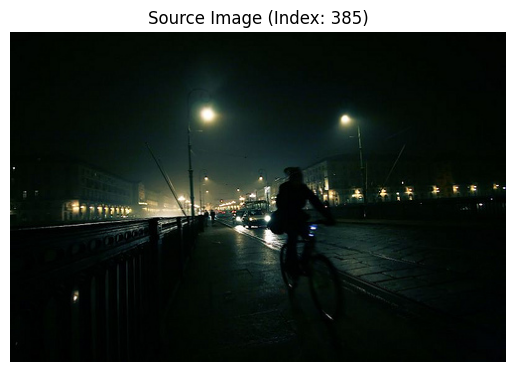

In [12]:
import sacrebleu
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import gzip
from datasets import Dataset, DatasetDict, Image as HFImage

# --- 1. Re-create your *correct* dataset to get image paths ---
# (This is the code you provided from 2.ipynb)

print("Loading the correct dataset to get image paths...")
image_folder_path = "flickr30k/Images" # Corrected path
repo_path = "dataset"
final_dataset = None

dataset_dict = {}
split_map = {
    "train": {"en": "train.en.gz", "de": "train.de.gz", "files": "train.txt"},
    "validation": {"en": "val.en.gz", "de": "val.de.gz", "files": "val.txt"},
    "test": {"en": "test_2016_flickr.en.gz", "de": "test_2016_flickr.de.gz", "files": "test_2016_flickr.txt"}
}
text_path = os.path.join(repo_path, "data", "task1", "raw")
files_path = os.path.join(repo_path, "data", "task1", "image_splits")

for split_name, paths in split_map.items():
    with gzip.open(os.path.join(text_path, paths['en']), 'rt', encoding='utf-8') as f: en_sents = f.read().strip().split('\n')
    with gzip.open(os.path.join(text_path, paths['de']), 'rt', encoding='utf-8') as f: de_sents = f.read().strip().split('\n')
    with open(os.path.join(files_path, paths['files']), 'r', encoding='utf-8') as f: img_files = f.read().strip().split('\n')
    
    # Check for length mismatch
    if len(en_sents) != len(img_files) or len(de_sents) != len(img_files):
        print(f"Warning: Mismatch in {split_name}. Trimming to shortest list.")
        min_len = min(len(en_sents), len(de_sents), len(img_files))
        en_sents = en_sents[:min_len]
        de_sents = de_sents[:min_len]
        img_files = img_files[:min_len]
        
    data = {'image_path': [os.path.join(image_folder_path, fname) for fname in img_files], 'en': en_sents, 'de': de_sents}
    dataset_dict[split_name] = Dataset.from_dict(data)

final_dataset = DatasetDict(dataset_dict)
correct_test_data = final_dataset['test']
print("Correct test dataset loaded.")

# --- 2. Calculate Full Test Set BLEU Score ---
# (This part is unchanged, as it didn't need the image path)
print("\nCalculating BLEU score...")
hypotheses = []
references = []
test_dataloader_eval = DataLoader(test_dataset, batch_size=1, collate_fn=collate_fn_graph, shuffle=False)

for data_item in tqdm(test_dataloader_eval, desc="Calculating BLEU"):
    tgt_tokens = data_item['tgt_tokens'].cpu().numpy().T[0]
    translation = translate_sentence_graph(model, data_item)
    hypotheses.append(translation)
    ref_decoded = tokenizer_de.decode([t for t in tgt_tokens if t not in (SOS_IDX, EOS_IDX, PAD_IDX)])
    references.append(ref_decoded)

bleu = sacrebleu.corpus_bleu(hypotheses, [references])
print("\n" + "="*30)
print(f"--- FINAL BLEU SCORE: {bleu.score:.2f} ---")
print("="*30 + "\n")

# --- 3. Show a Random Live Example (FIXED) ---
print("Loading a random example for dynamic translation...")

# Pick a random index
# We use correct_test_data now, which has the same length
random_idx = random.randint(0, len(correct_test_data) - 1)

# Get the item from *our* dataset for the model
processed_item = test_dataset[random_idx]
# Get the item from the *correct* dataset for the display info
display_item = correct_test_data[random_idx]

# Collate the single item into a "batch of 1"
single_batch = collate_fn_graph([processed_item])

# Generate the translation
model_translation = translate_sentence_graph(model, single_batch)

# --- Display the results ---
img_path = display_item['image_path'] # <-- This is the fix

try:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Source Image (Index: {random_idx})")
    plt.savefig('random_example_image.png')
    print("Displaying random source image ('random_example_image.png')...")
except FileNotFoundError:
    print(f"Could not find image: {img_path}")

print("\n" + "-"*30)
print(f"Source (EN):      {display_item['en']}")
print(f"Model (DE):       {model_translation}")
print(f"Reference (DE):   {display_item['de']}")
print("-"*30)

Loading a random example for dynamic translation...
Displaying random source image ('random_example_image.png')...

------------------------------
Source (EN):      A young girl sitting on a wooden chair.
Model (DE):       Ein junges Mädchen sitzt auf einem Holz stuhl .
Reference (DE):   Ein junges Mädchen sitzt auf einem Holzstuhl.
------------------------------


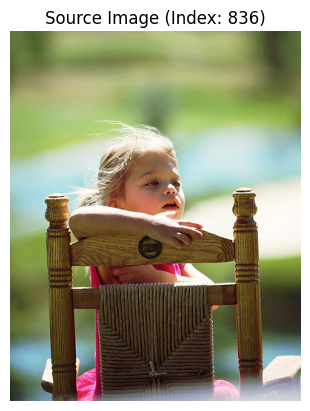

In [ ]:
# --- 3. Show a Random Live Example (FIXED) ---
print("Loading a random example for dynamic translation...")

# Pick a random index
# We use correct_test_data now, which has the same length
random_idx = random.randint(0, len(correct_test_data) - 1)

# Get the item from *our* dataset for the model
processed_item = test_dataset[random_idx]
# Get the item from the *correct* dataset for the display info
display_item = correct_test_data[random_idx]

# Collate the single item into a "batch of 1"
single_batch = collate_fn_graph([processed_item])

# Generate the translation
model_translation = translate_sentence_graph(model, single_batch)

# --- Display the results ---
img_path = display_item['image_path'] 

try:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Source Image (Index: {random_idx})")
    plt.savefig('random_example_image.png')
    print("Displaying random source image ('random_example_image.png')...")
except FileNotFoundError:
    print(f"Could not find image: {img_path}")

print("\n" + "-"*30)
print(f"Source (EN):      {display_item['en']}")
print(f"Model (DE):       {model_translation}")
print(f"Reference (DE):   {display_item['de']}")
print("-"*30)